<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Загрузка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>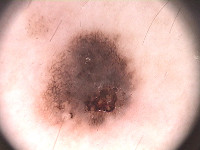</td><td>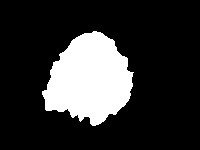</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=3eca1e72-322d-4955-a65e-1f4ed44bc7d5
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 81.7MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

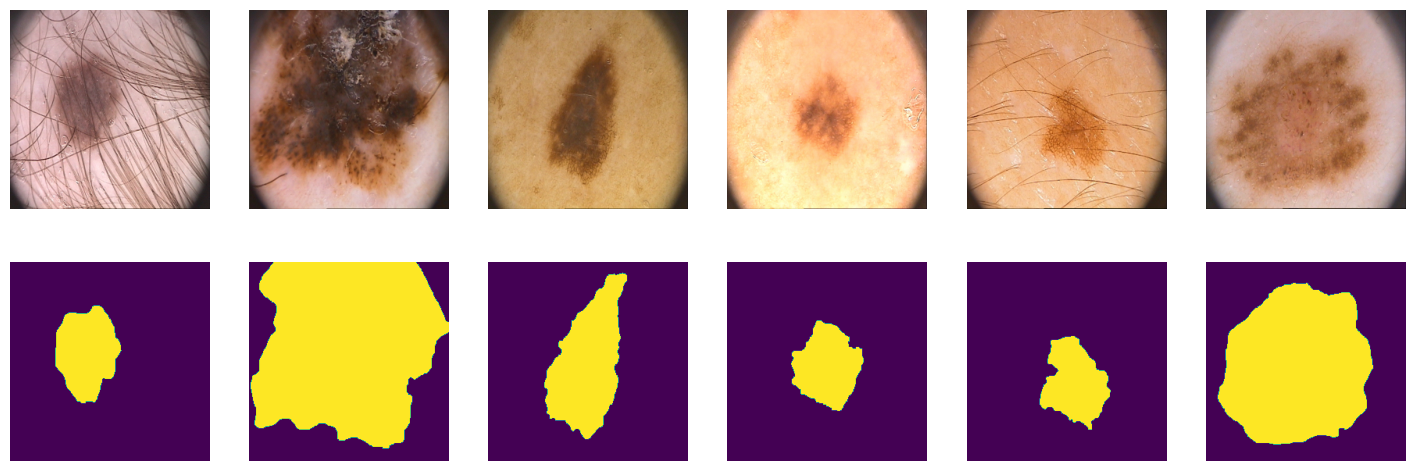

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [8]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=True)

In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Метрика

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 23.9 MB/s eta 0:00:00


In [ ]:
!pip install segmentation_models_pytorch

In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## BCE Loss [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch.nn.functional as F
import torch.nn as nn

In [14]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [34]:
def bce_loss(y_pred, y_real):
  # TODO
  return torch.sum(y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred)))

def bce_true(y_pred, y_real):
  # TODO
  sigmoid_pred = torch.sigmoid(y_pred)  # Вычисляем сигмоиду
  return torch.sum(-y_real * torch.log(sigmoid_pred) - (1 - y_real) * torch.log(1 - sigmoid_pred))

Проверим корректность работы на простом примере

In [32]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 0.7758700847625732
BCE loss честно посчитанный = 4.655220985412598
BCE loss from torch bce_torch = 4.655220985412598
BCE loss from torch with logits bce_torch = 4.6552205085754395


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [35]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [18]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 15.671195983886719
BCE loss честно посчитанный = 15.671195983886719
BCE loss from torch bce_torch = 15.671195983886719
BCE loss from torch with logits bce_torch = 15.671194076538086


In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [20]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.30MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 4.02MB/s]
Download completed


In [21]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

<ipython-input-21-cd9dbfff2c1b>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
<ipython-input-

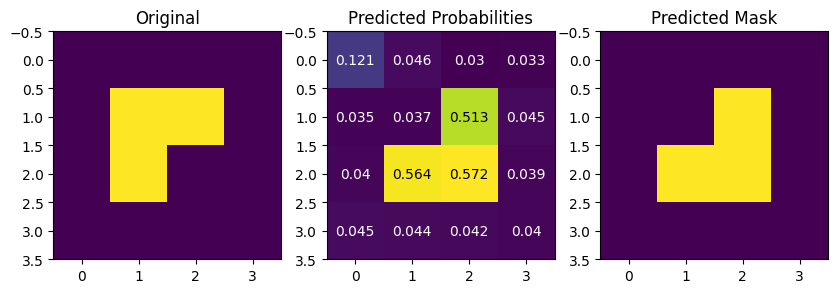

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [23]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

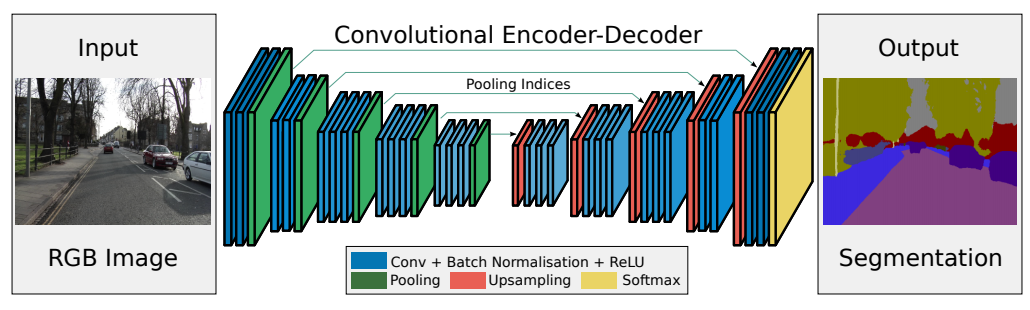

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239


In [25]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        # Each enc_conv/dec_conv block should look like this:
        # nn.Sequential(
        #     nn.Conv2d(...),
        #     ... (2 or 3 conv layers with relu and batchnorm),
        # )
        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.pool0 = nn.MaxPool2d(kernel_size=2, return_indices=True)  # 256 -> 128
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, return_indices=True) # 128 -> 64
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, return_indices=True) # 64 -> 32
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(kernel_size=2, return_indices=True) # 32 -> 16

        # bottleneck
        self.bottleneck_conv = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, return_indices=True),
            nn.MaxUnpool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.bottleneck_conv0 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.bottleneck_pool = nn.MaxPool2d(kernel_size=2, return_indices=True) # 16 -> 8
        self.bottleneck_upsample = nn.MaxUnpool2d(2, stride=2) # 8 -> 16
        self.bottleneck_conv1  = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # decoder (upsampling)
        self.upsample0 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 16 -> 32
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample1 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.upsample2 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.upsample3 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1),
            nn.ReLU(),
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x):
        # encoder
        e0, e0_indexes = self.pool0(self.enc_conv0(x))
        e1, e1_indexes = self.pool1(self.enc_conv1(e0))
        e2, e2_indexes = self.pool2(self.enc_conv2(e1))
        e3, e3_indexes = self.pool3(self.enc_conv3(e2))

        # bottleneck
        b0, b0_indexes = self.bottleneck_pool(self.bottleneck_conv0(e3))
        b1 = self.bottleneck_conv1(self.bottleneck_upsample(b0, b0_indexes))

        # decoder
        d0 = self.dec_conv0(self.upsample0(b1, e3_indexes))
        d1 = self.dec_conv1(self.upsample1(d0, e2_indexes))
        d2 = self.dec_conv2(self.upsample2(d1, e1_indexes))
        d3 = self.dec_conv3(self.upsample3(d2, e0_indexes))  # no activation
        return d3

In [26]:
segnet_model = SegNet().to(device)

## Тренировка [1 балл]

Напишите функцию для обучения модели.

In [27]:
from tqdm.notebook import tqdm

In [28]:
def train(model, opt, loss_fn, epochs, data_tr, data_val):
    X_val, Y_val = next(iter(data_val))
    train_loss, val_loss, val_acc = [], [], []

    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch in data_tr:
            # data to device
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred) # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate loss to show the user
            avg_loss += loss / len(data_tr)
        toc = time()
        print('loss: %f' % avg_loss)

        train_loss.append(avg_loss)

        # show intermediate results
        model.eval()  # testing mode
        Y_hat = model(X_val.to(device)).detach().cpu() # detach and put into cpu

        sum_val_loss, sum_val_acc = 0, 0
        for X_val_batch, Y_val_batch in data_val:
            X_val_batch, Y_val_batch = X_val_batch.to(device), Y_val_batch.to(device)

            with torch.set_grad_enabled(False):
                vall_loss = loss_fn(Y_val_batch, model(X_val_batch))
            sum_val_loss += vall_loss

            Y_val_pred = torch.sigmoid(model(X_val_batch)) > 0.5
            sum_val_acc += iou_score (Y_val_pred, Y_val_batch).mean().item()

        val_loss.append(sum_val_loss / len(data_val))
        val_acc.append(sum_val_acc / len(data_val))

        # Visualize tools
        clear_output(wait=True)
        for k in range(6):
            plt.subplot(2, 6, k+1)
            plt.imshow(np.rollaxis(X_val[k].numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(2, 6, k+7)
            plt.imshow(Y_hat[k, 0], cmap='gray')
            plt.title('Output')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()

    return train_loss, val_loss, val_acc

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

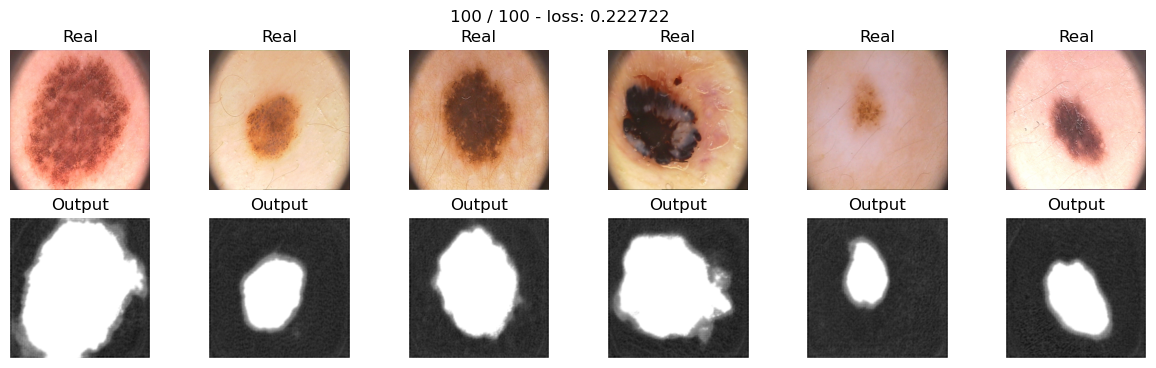

In [ ]:
max_epochs = 100
optim = torch.optim.Adam(segnet_model.parameters())
segnet_bce_train_loss, segnet_bce_val_loss, segnet_bce_val_acc = \
    train(segnet_model, optim, bce_loss, max_epochs, train_dataloader , valid_dataloader)

## Инференс [1 балл]

После обучения модели напишите фукнцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [ ]:
def predict(model, data):
    model.eval()  # testing mode
    Y_pred = [ X_batch for X_batch, _ in data]
    return np.array(Y_pred)

In [ ]:
def score_model(model, metric, data):
    model.eval()  # testing mode
    scores = 0
    for X_batch, Y_label in data:
        Y_pred = torch.sigmoid(model(X_batch.to(device))).round() #TODO
        scores += metric(Y_pred, Y_label.to(device)).mean().item()

    return scores/len(data)

In [ ]:
score_model(segnet_model, iou_score, test_dataloader)

0.7500000298023224

# Мир других лоссов!

## Дополнительные функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [39]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5, epsilon: float = 1e-8):
    '''
    Это именно метрика, не лосс.
    '''
    # TODO
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    intersection = torch.sum(preds * labels)
    total = torch.sum(preds) + torch.sum(labels)

    score = (2 * intersection + epsilon) / (total + epsilon)
    return score.item()

Проверим на корректность функцию dice_score:

In [40]:
from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.6667, device='cuda:0')

In [41]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [43]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, epsilon: float = 1e-8):
    '''
    Это лосс.
    '''
    # TODO
    probs = torch.sigmoid(logits)

    intersection = torch.sum(probs * labels)
    total = torch.sum(probs) + torch.sum(labels)

    dice_coeff = (2 * intersection + epsilon) / (total + epsilon)

    return 1 - dice_coeff

Проверка на корректность:

In [47]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [48]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [88]:
def focal_loss(y_real: torch.Tensor, y_pred: torch.Tensor, gamma: float = 2.0, alpha: float = 0.25, eps: float = 1e-8, reduction: str = 'mean') -> torch.Tensor:
    probs = torch.sigmoid(y_pred)

    pos_loss = -alpha * ((1 - probs) ** gamma) * y_real * torch.log(probs + eps)
    neg_loss = -(1 - alpha) * (probs ** gamma) * (1 - y_real) * torch.log(1 - probs + eps)

    loss = pos_loss + neg_loss

    if reduction == 'mean':
        loss = loss.mean()
    elif reduction == 'sum':
        loss = loss.sum()

    return loss

Проверка корректности функции:

In [82]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(0.4146)

In [87]:
assert torch.isclose(sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=0.25, gamma=2.0, reduction='sum'), focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0, alpha=0.25, reduction='sum'))

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [52]:
def ssim_loss(y_real, y_pred):
    eps = 1e-6
    y_real = y_real - y_real.mean()
    y_pred = y_pred - y_pred.mean()
    num = (y_real - y_pred) ** 2
    den = y_real**2 + y_pred**2 + (len(y_real) - 1) * eps
    return (num / den).mean()

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



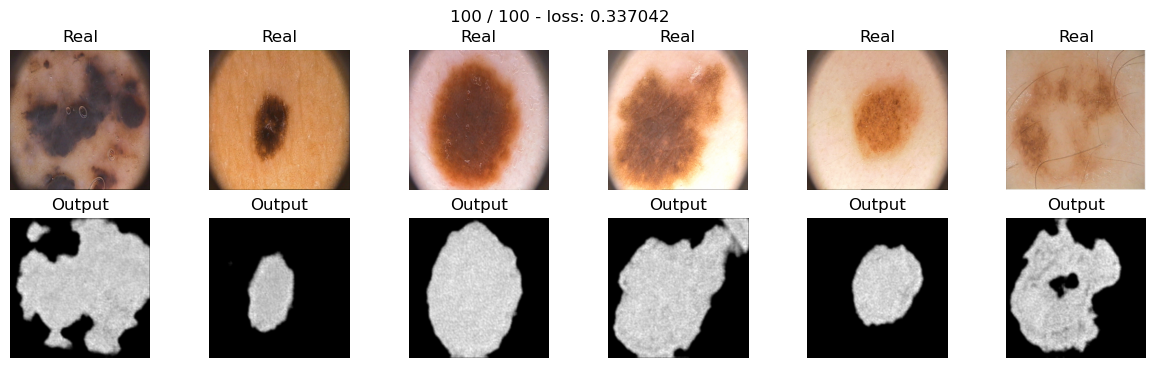

In [ ]:
model_dice = SegNet().to(device)

max_epochs = 100
optimaizer = torch.optim.Adam(model_dice.parameters())
segnet_dice_train_loss, segnet_dice_val_loss, segnet_dice_val_acc = \
    train(model_dice, optimaizer, dice_loss, max_epochs, train_dataloader , valid_dataloader)

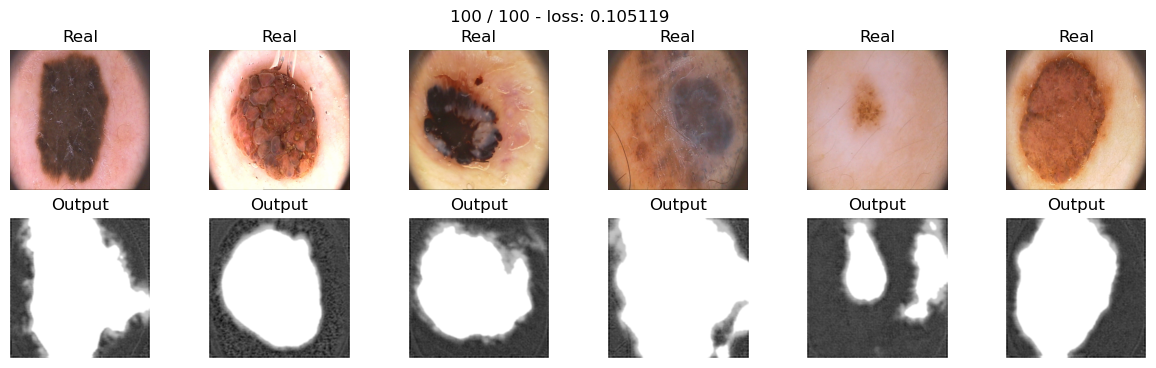

In [ ]:
model_focal = SegNet().to(device)

max_epochs = 100
optimaizer = torch.optim.Adam(model_focal.parameters())
segnet_focal_train_loss, segnet_focal_val_loss, segnet_focal_val_acc = \
    train(model_focal, optimaizer, focal_loss, max_epochs, train_dataloader , valid_dataloader)

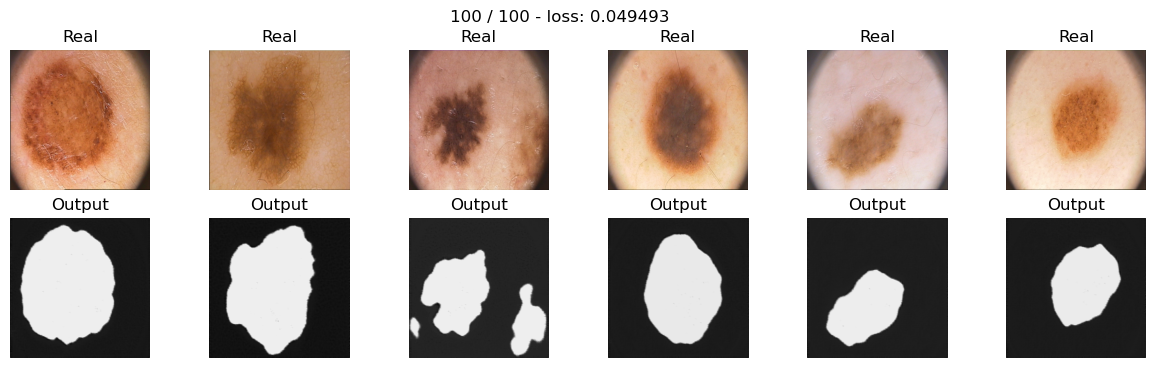

In [ ]:
torch.cuda.empty_cache()
model_ssim = SegNet().to(device)

max_epochs = 100
optimizer = torch.optim.Adam(model_ssim.parameters())
segnet_ssim_train_loss, segnet_ssim_val_loss, segnet_ssim_val_acc = \
    train(model_ssim, optimizer, ssim_loss, max_epochs, train_dataloader , valid_dataloader)

# Новая модель!

## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

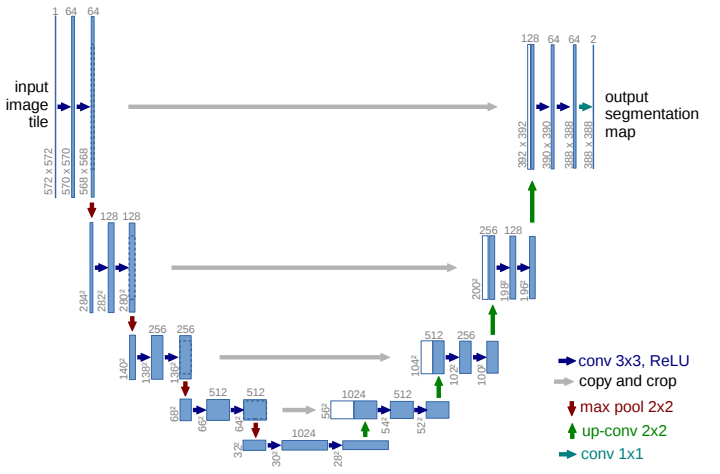

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        # Each enc_conv/dec_conv block should look like this:
        # nn.Sequential(
        #     nn.Conv2d(...),
        #     ... (2 or 3 conv layers with relu and batchnorm),
        # )
        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 = nn.MaxPool2d(2)  # 256 -> 128
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2) # 128 -> 64
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2) # 64 -> 32
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(2) # 32 -> 16

        # bottleneck
        self.bottleneck_conv = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU()
        )

        # decoder (upsampling)
        self.upsample0 = nn.Upsample(scale_factor=2) # 16 -> 32
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(1024+512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.upsample1 = nn.Upsample(scale_factor=2) # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(512+256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.upsample2 = nn.Upsample(scale_factor=2)  # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(256+128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample3 = nn.Upsample(scale_factor=2)  # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(128+64, 1, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1),
            nn.ReLU(),
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x):
        # encoder
        l0 = self.enc_conv0(x)
        e0 = self.pool0(l0)
        l1 = self.enc_conv1(e0)
        e1 = self.pool1(l1)
        l2 = self.enc_conv2(e1)
        e2 = self.pool2(l2)
        l3 = self.enc_conv3(e2)
        e3 = self.pool3(l3)

        # bottleneck
        b = self.bottleneck_conv(e3)

        # decoder
        d0 = self.dec_conv0(torch.cat([self.upsample0(b), l3], dim=1))
        d1 = self.dec_conv1(torch.cat([self.upsample1(d0), l2], dim=1))
        d2 = self.dec_conv2(torch.cat([self.upsample2(d1), l1], dim=1))
        d3 = self.dec_conv3(torch.cat([self.upsample3(d2), l0], dim=1))  # no activation
        return d3

In [ ]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



Визуально результаты SegNet и Unet очень похожи, однако, SegNet в некторых сложных местах может сегментировать немного неверно, поэтому я бы сказала, что визуально у UNet результат лучше, чем у SegNet.

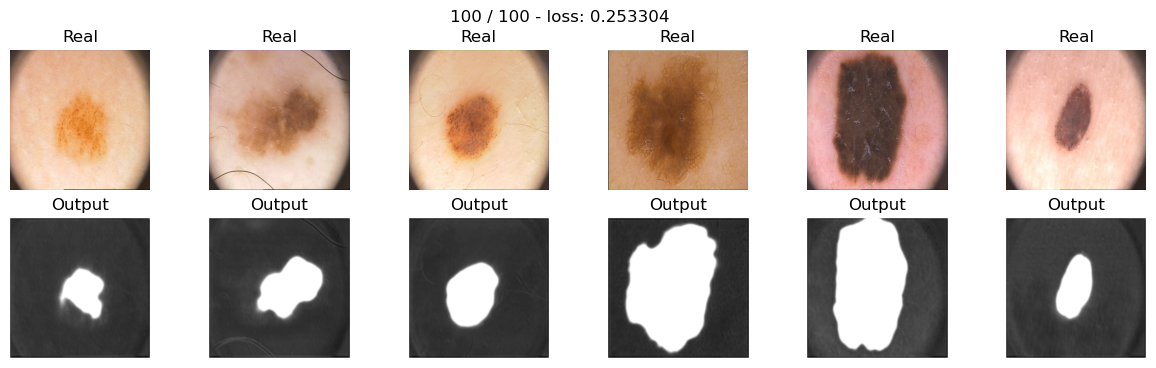

In [ ]:
max_epochs = 100
optim = torch.optim.Adam(unet_model.parameters())
unet_bce_train_loss, unet_bce_val_loss, unet_bce_val_acc = \
    train(unet_model, optim, bce_loss, max_epochs, train_dataloader , valid_dataloader)

In [ ]:
score_model(unet_model, iou_score, test_dataloader)

0.5319999903440475

In [ ]:
unet_dice_model = UNet().to(device)

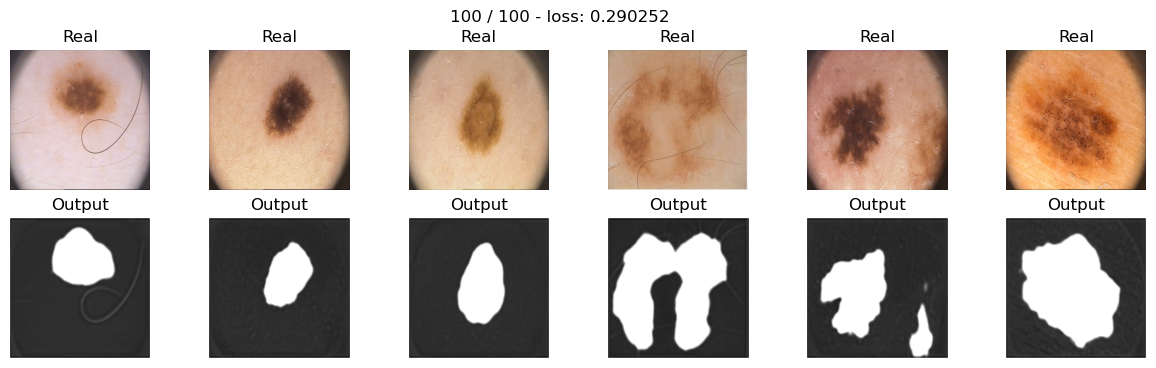

In [ ]:
max_epochs = 100
optim = torch.optim.Adam(unet_dice_model.parameters())
unet_dice_train_loss, unet_dice_val_loss, unet_dice_val_acc = \
    train(unet_dice_model, optim, dice_loss, max_epochs, train_dataloader , valid_dataloader)

In [ ]:
score_model(unet_dice_model, iou_score, test_dataloader)

0.7320000231266022

In [ ]:
unet_focal_model = UNet().to(device)

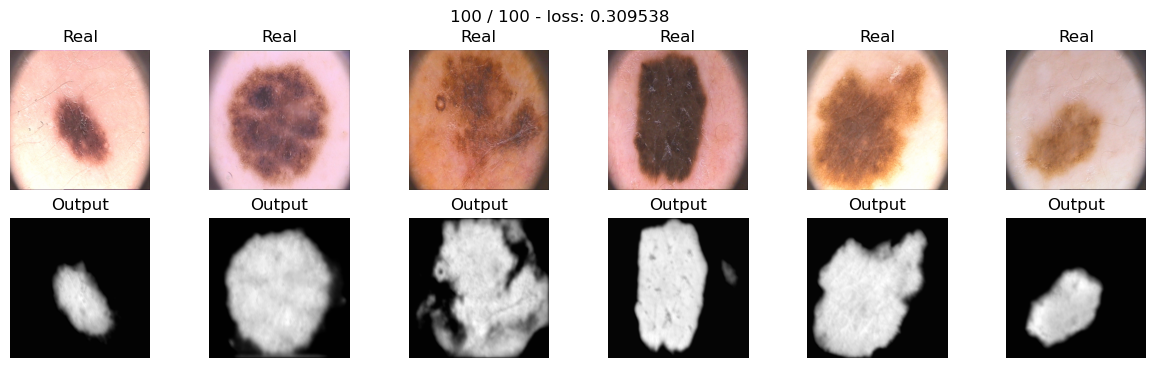

In [ ]:
max_epochs = 100
optim = torch.optim.Adam(unet_focal_model.parameters())
unet_focal_train_loss, unet_focal_val_loss, unet_focal_val_acc = \
    train(unet_focal_model, optim, focal_loss, max_epochs, train_dataloader , valid_dataloader)

In [ ]:
score_model(unet_focal_model, iou_score, test_dataloader)

0.7299999594688416

In [ ]:
unet_ssim_model = UNet().to(device)

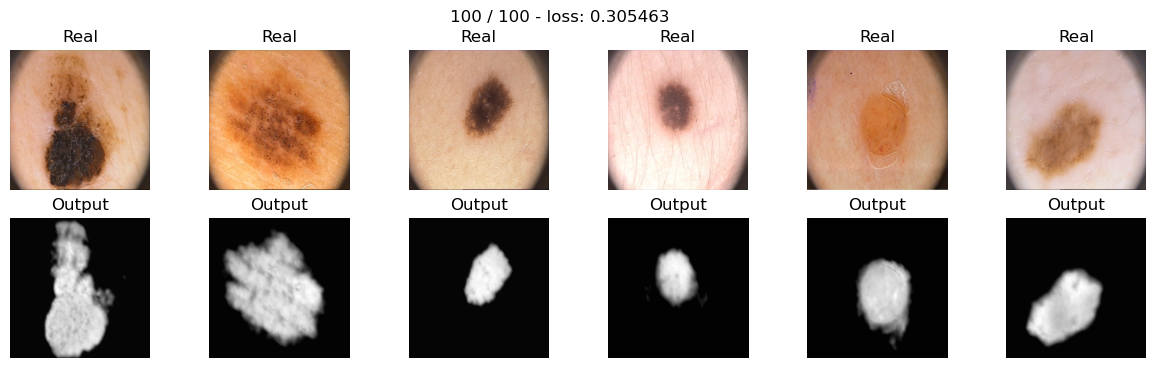

In [ ]:
max_epochs = 100
optim = torch.optim.Adam(unet_ssim_model.parameters())
unet_ssim_train_loss, unet_ssim_val_loss, unet_ssim_val_acc = \
    train(unet_focal_model, optim, focal_loss, max_epochs, train_dataloader , valid_dataloader)

In [ ]:
score_model(unet_ssim_model, iou_score, test_dataloader)

0.08399999979883432

Новая модель путем изменения типа пулинга:

 **Max-Pooling** for the downsampling and **nearest-neighbor Upsampling** for the upsampling.

Down-sampling:

        conv = nn.Conv2d(3, 64, 3, padding=1)
        pool = nn.MaxPool2d(3, 2, padding=1)

Up-Sampling

        upsample = nn.Upsample(32)
        conv = nn.Conv2d(64, 64, 3, padding=1)

Замените max-pooling на convolutions с stride=2 и upsampling на transpose-convolutions с stride=2.


In [ ]:
class UNet2(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        # Each enc_conv/dec_conv block should look like this:
        # nn.Sequential(
        #     nn.Conv2d(...),
        #     ... (2 or 3 conv layers with relu and batchnorm),
        # )
        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 3), stride=2, padding=1)  # 256 -> 128
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3, 3), stride=2, padding=1) # 128 -> 64
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3, 3), stride=2, padding=1) # 64 -> 32
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool3 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=(3, 3), stride=2, padding=1) # 32 -> 16

        # bottleneck
        self.bottleneck_conv = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU()
        )

        # decoder (upsampling)
        self.upsample0 = nn.ConvTranspose2d(1024, 1024, 3, 2, 1, output_padding=1) # 16 -> 32
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(1024+512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.upsample1 = nn.ConvTranspose2d(512, 512, 3, 2, 1, output_padding=1) # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(512+256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.upsample2 = nn.ConvTranspose2d(256, 256, 3, 2, 1, output_padding=1)  # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(256+128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample3 = nn.ConvTranspose2d(128, 128, 3, 2, 1, output_padding=1)  # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(128+64, 1, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1),
            nn.ReLU(),
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)
        )

        self.dec_conv_out = nn.Conv2d(in_channels=64, out_channels=1, kernel_size=1, padding=0)

    def forward(self, x):
        # encoder
        l0 = self.enc_conv0(x)
        e0 = self.pool0(l0)
        l1 = self.enc_conv1(e0)
        e1 = self.pool1(l1)
        l2 = self.enc_conv2(e1)
        e2 = self.pool2(l2)
        l3 = self.enc_conv3(e2)
        e3 = self.pool3(l3)

        # bottleneck
        b = self.bottleneck_conv(e3)

        # decoder
        d0 = self.dec_conv0(torch.cat([self.upsample0(b), l3], dim=1))
        d1 = self.dec_conv1(torch.cat([self.upsample1(d0), l2], dim=1))
        d2 = self.dec_conv2(torch.cat([self.upsample2(d1), l1], dim=1))
        d3 = self.dec_conv3(torch.cat([self.upsample3(d2), l0], dim=1)) # no activation
        return d3

In [ ]:
unet2_model = UNet2().to(device)

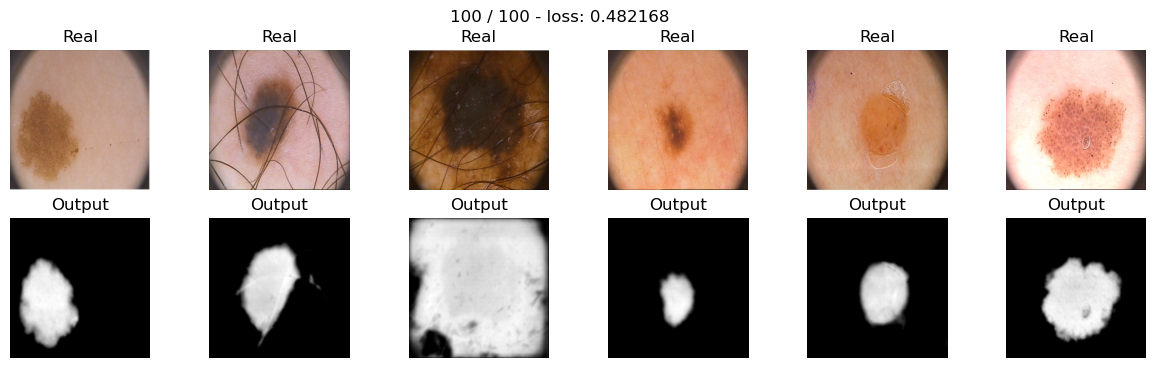

In [ ]:
unet2_bce_train_loss, unet2_bce_val_loss, unet2_bce_val_acc = \
    train(unet2_model, torch.optim.Adam(unet2_model.parameters()), bce_loss, 100, train_dataloader , valid_dataloader)

In [ ]:
score_model(unet2_model, iou_score, test_dataloader)

0.6499999761581421

In [ ]:
import pickle

# Объект для сохранения
results = {
    'train_loss': unet2_bce_train_loss,
    'val_loss': unet2_bce_val_loss,
    'val_acc': unet2_bce_val_acc
}

# Сохранение в файл
with open('unet2_results.pkl', 'wb') as f:
    pickle.dump(results, f)

In [ ]:
# Загрузка из файла
with open('unet2_results.pkl', 'rb') as f:
    loaded_results = pickle.load(f)

# Доступ к загруженным значениям
unet2_bce_train_loss = loaded_results['train_loss']
unet2_bce_val_loss = loaded_results['val_loss']
unet2_bce_val_acc = loaded_results['val_acc']

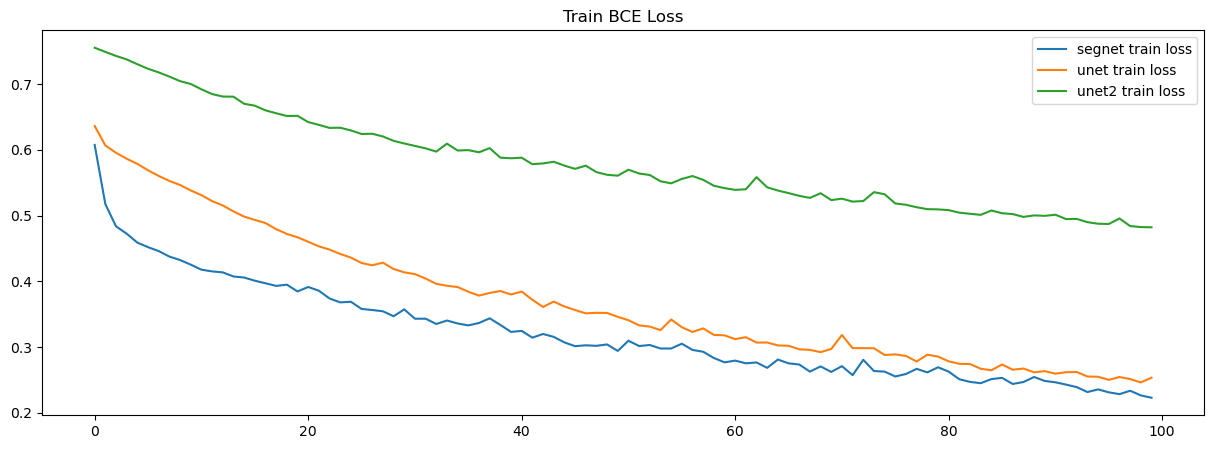

In [ ]:
segnet_bce_train_loss_ = []
for el in segnet_bce_train_loss:
    segnet_bce_train_loss_.append(el.item())

unet_bce_train_loss_ = []
for el in unet_bce_train_loss:
    unet_bce_train_loss_.append(el.item())

unet2_bce_train_loss_ = []
for el in unet2_bce_train_loss:
    unet2_bce_train_loss_.append(el.item())

segnet_bce_val_loss_ = []
for el in segnet_bce_val_loss:
    segnet_bce_val_loss_.append(el.item())

unet_bce_val_loss_ = []
for el in unet_bce_val_loss:
    unet_bce_val_loss_.append(el.item())

unet2_bce_val_loss_ = []
for el in unet2_bce_val_loss:
    unet2_bce_val_loss_.append(el.item())

plt.figure(figsize=(15,5))
plt.plot(segnet_bce_train_loss_, label='segnet train loss')
plt.plot(unet_bce_train_loss_, label='unet train loss')
plt.plot(unet2_bce_train_loss_, label='unet2 train loss')
plt.title('Train BCE Loss')

plt.legend()
plt.show()

Тут SegNet выглядит лучше, Unet2 хуже всех..

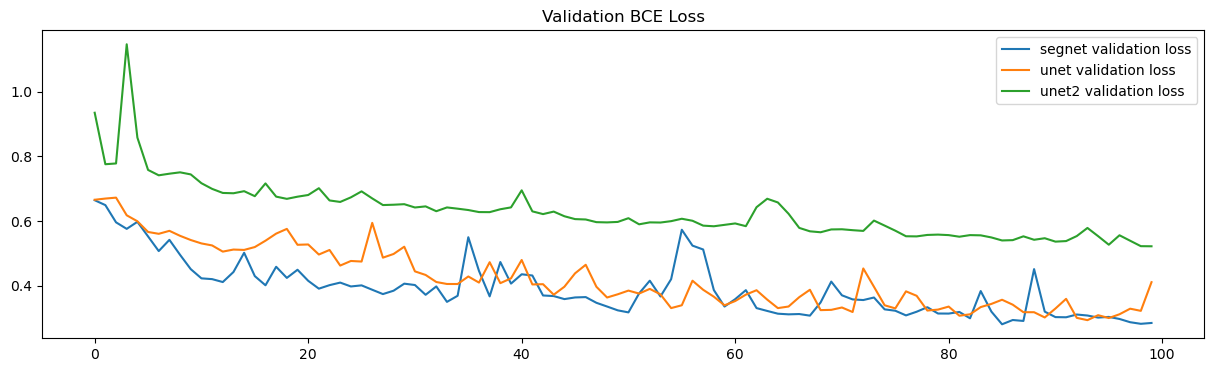

In [ ]:
plt.plot(segnet_bce_val_loss_, label='segnet validation loss')
plt.plot(unet_bce_val_loss_, label='unet validation loss')
plt.plot(unet2_bce_val_loss_, label='unet2 validation loss')
plt.title('Validation BCE Loss')

plt.legend()
plt.show()

На валидации ситуация примерно такая же

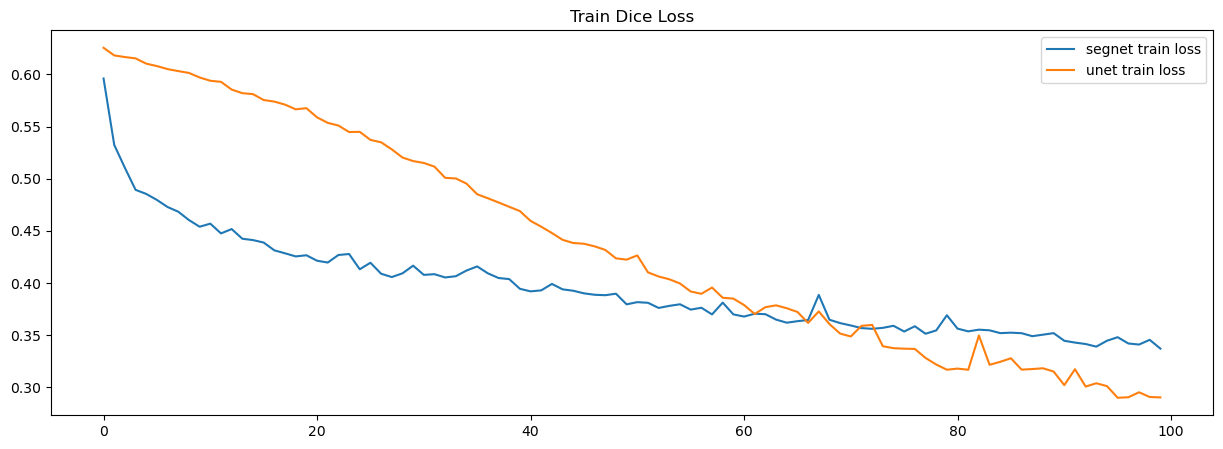

In [ ]:
segnet_dice_train_loss_ = []
for el in segnet_dice_train_loss:
    segnet_dice_train_loss_.append(el.item())

unet_dice_train_loss_ = []
for el in unet_dice_train_loss:
    unet_dice_train_loss_.append(el.item())

segnet_dice_val_loss_ = []
for el in segnet_dice_val_loss:
    segnet_dice_val_loss_.append(el.item())

unet_dice_val_loss_ = []
for el in unet_dice_val_loss:
    unet_dice_val_loss_.append(el.item())

plt.figure(figsize=(15,5))
plt.plot(segnet_dice_train_loss_, label='segnet train loss')
plt.plot(unet_dice_train_loss_, label='unet train loss')
plt.title('Train Dice Loss')

plt.legend()
plt.show()

Тут Unet выглядит лучше

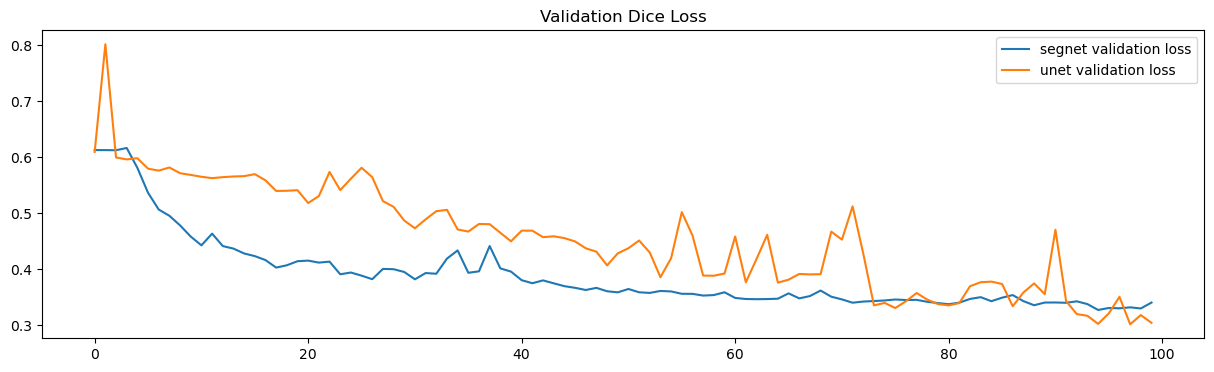

In [ ]:
plt.plot(segnet_dice_val_loss_, label='segnet validation loss')
plt.plot(unet_dice_val_loss_, label='unet validation loss')
plt.title('Validation Dice Loss')

plt.legend()
plt.show()

На валидации же лосс у SegNet выглядит плавнее, хотя на последней эпохе лосс у Unet ниже

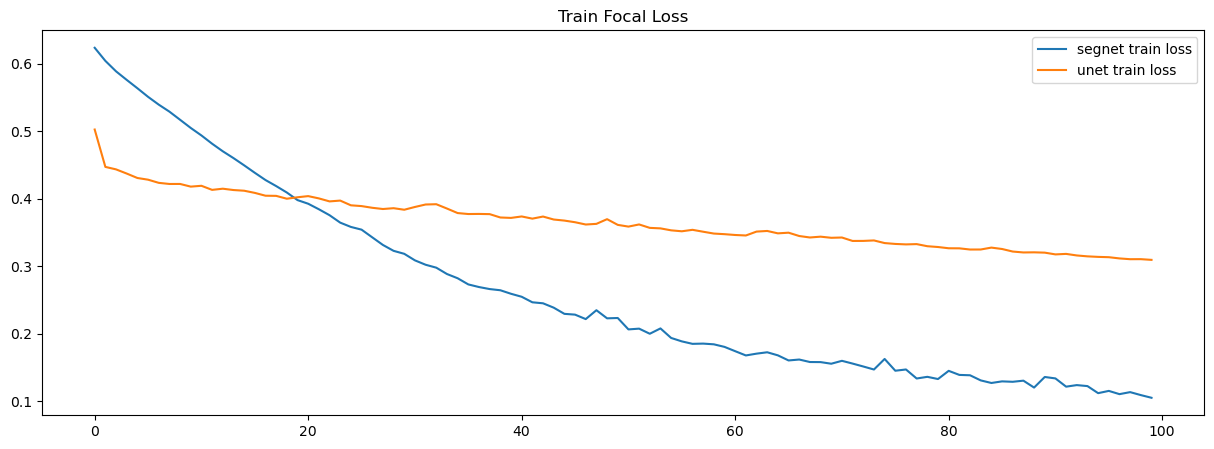

In [ ]:
segnet_focal_train_loss_ = []
for el in segnet_focal_train_loss:
    segnet_focal_train_loss_.append(el.item())

unet_focal_train_loss_ = []
for el in unet_focal_train_loss:
    unet_focal_train_loss_.append(el.item())

segnet_focal_val_loss_ = []
for el in segnet_focal_val_loss:
    segnet_focal_val_loss_.append(el.item())

unet_focal_val_loss_ = []
for el in unet_focal_val_loss:
    unet_focal_val_loss_.append(el.item())

plt.figure(figsize=(15,5))
plt.plot(segnet_focal_train_loss_, label='segnet train loss')
plt.plot(unet_focal_train_loss_, label='unet train loss')
plt.title('Train Focal Loss')

plt.legend()
plt.show()

SegNet показывает более хороший результат, чем Unet

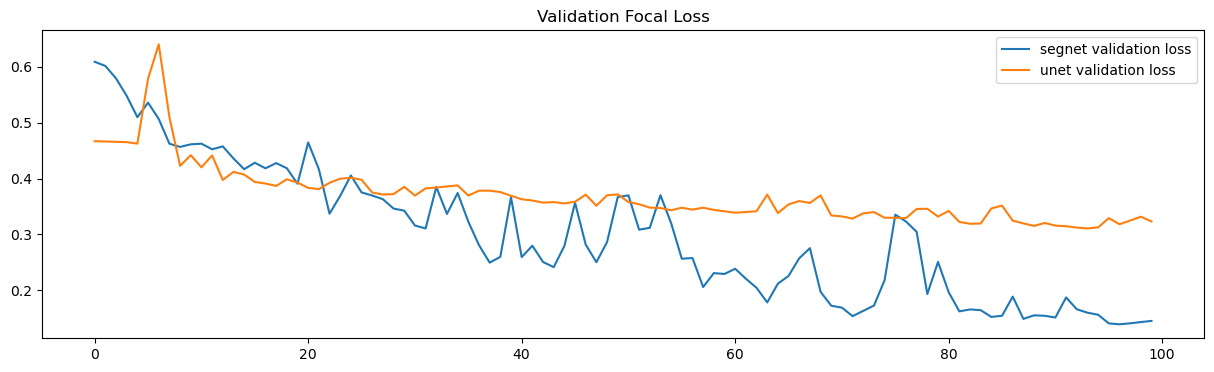

In [ ]:
plt.plot(segnet_focal_val_loss_, label='segnet validation loss')
plt.plot(unet_focal_val_loss_, label='unet validation loss')
plt.title('Validation Focal Loss')

plt.legend()
plt.show()

На валидации ситуация примрно такая же, но лосс немного колеблется

In [ ]:
segnet_ssim_train_loss_ = []
for el in segnet_ssim_train_loss:
    segnet_ssim_train_loss_.append(el.item())

segnet_ssim_val_loss_ = []
for el in segnet_ssim_val_loss:
    segnet_ssim_val_loss_.append(el.item())

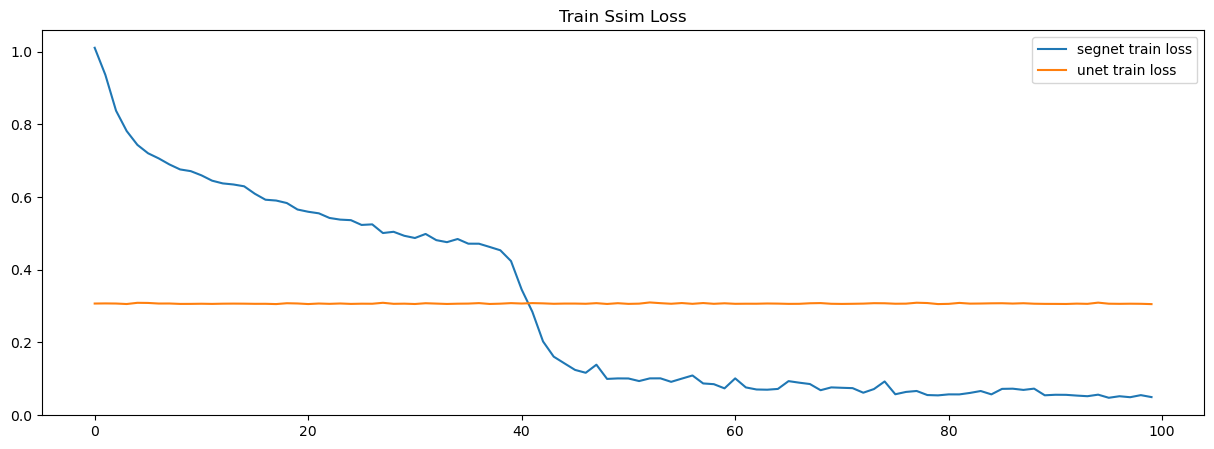

In [ ]:
segnet_ssim_train_loss_ = []
for el in segnet_ssim_train_loss:
    segnet_ssim_train_loss_.append(el.item())

unet_ssim_train_loss_ = []
for el in unet_ssim_train_loss:
    unet_ssim_train_loss_.append(el.item())

segnet_ssim_val_loss_ = []
for el in segnet_ssim_val_loss:
    segnet_ssim_val_loss_.append(el.item())

unet_ssim_val_loss_ = []
for el in unet_focal_val_loss:
    unet_ssim_val_loss_.append(el.item())

plt.figure(figsize=(15,5))
plt.plot(segnet_ssim_train_loss_, label='segnet train loss')
plt.plot(unet_ssim_train_loss_, label='unet train loss')
plt.title('Train Ssim Loss')

plt.legend()
plt.show()

SegNet показывает результат гораздо лучше

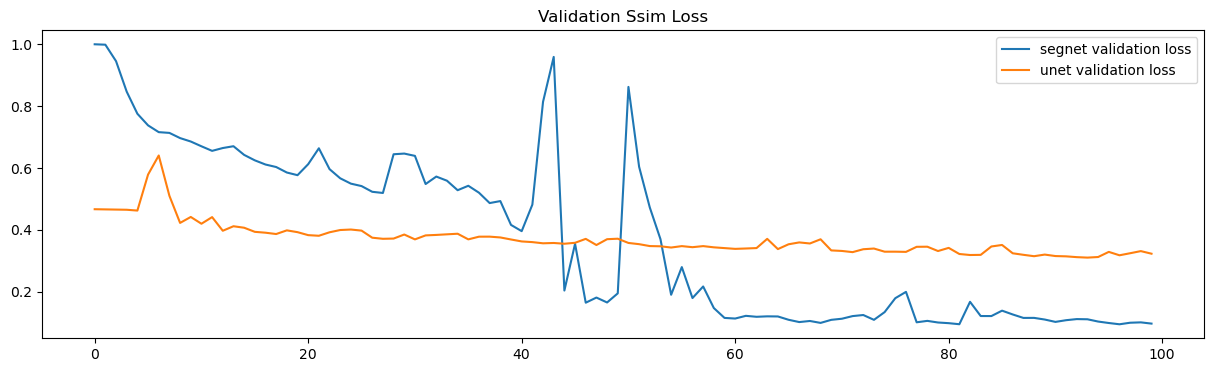

In [ ]:
plt.plot(segnet_ssim_val_loss_, label='segnet validation loss')
plt.plot(unet_ssim_val_loss_, label='unet validation loss')
plt.title('Validation Ssim Loss')

plt.legend()
plt.show()

Несмотря на некоторые колебания, SegNet все еще показывает хороший результат

Теперь посмотрем на каждый лосс у отедльных моделей

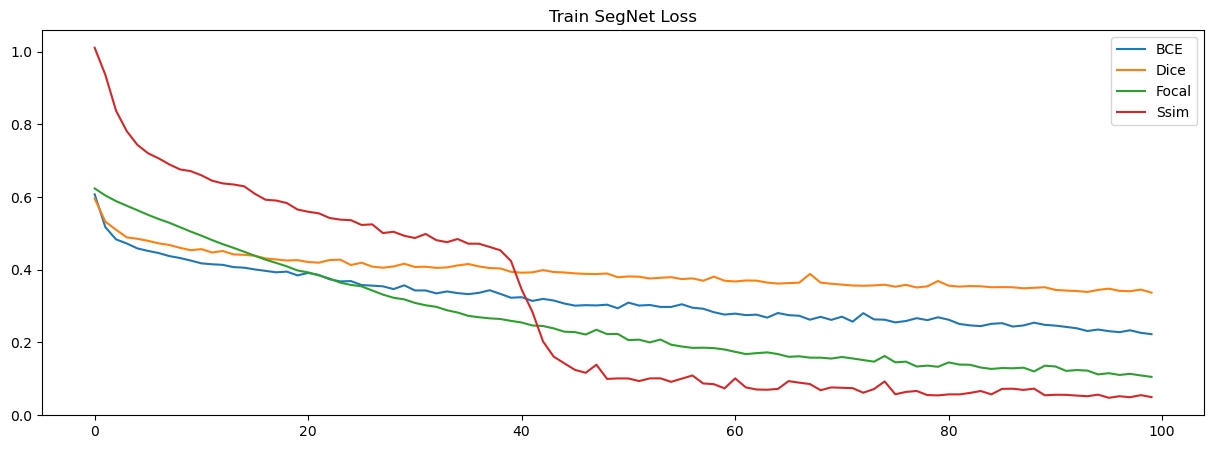

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(segnet_bce_train_loss_, label='BCE')
plt.plot(segnet_dice_train_loss_, label='Dice')
plt.plot(segnet_focal_train_loss_, label='Focal')
plt.plot(segnet_ssim_train_loss_, label='Ssim')
plt.title('Train SegNet Loss')

plt.legend()
plt.show()

У SegNet лучший результат при Ssim лосс, хотя изначально он был гораздо выше, чем у остальных

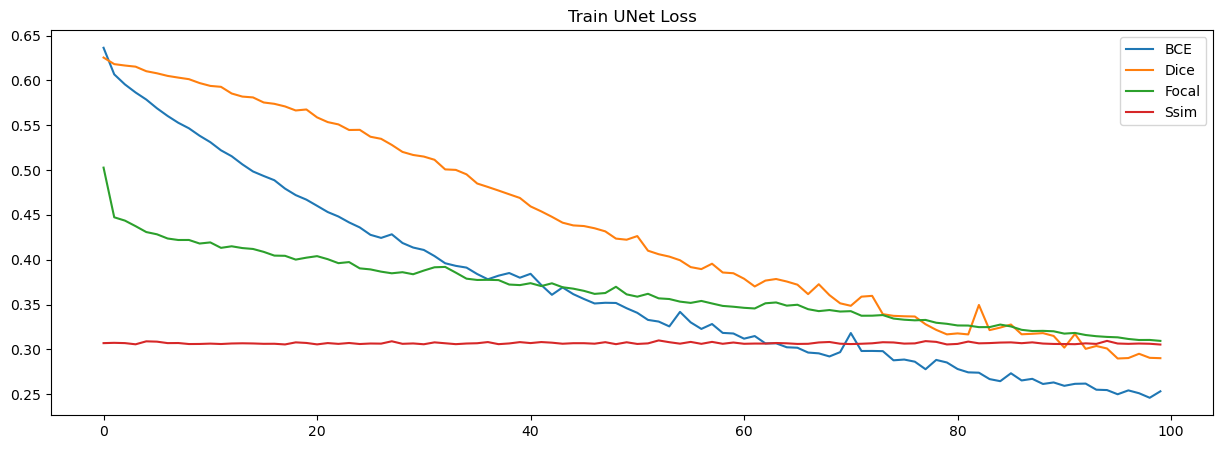

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(unet_bce_train_loss_, label='BCE')
plt.plot(unet_dice_train_loss_, label='Dice')
plt.plot(unet_focal_train_loss_, label='Focal')
plt.plot(unet_ssim_train_loss_, label='Ssim')
plt.title('Train UNet Loss')

plt.legend()
plt.show()

У Unet же, лучший результат при BCE лоссе

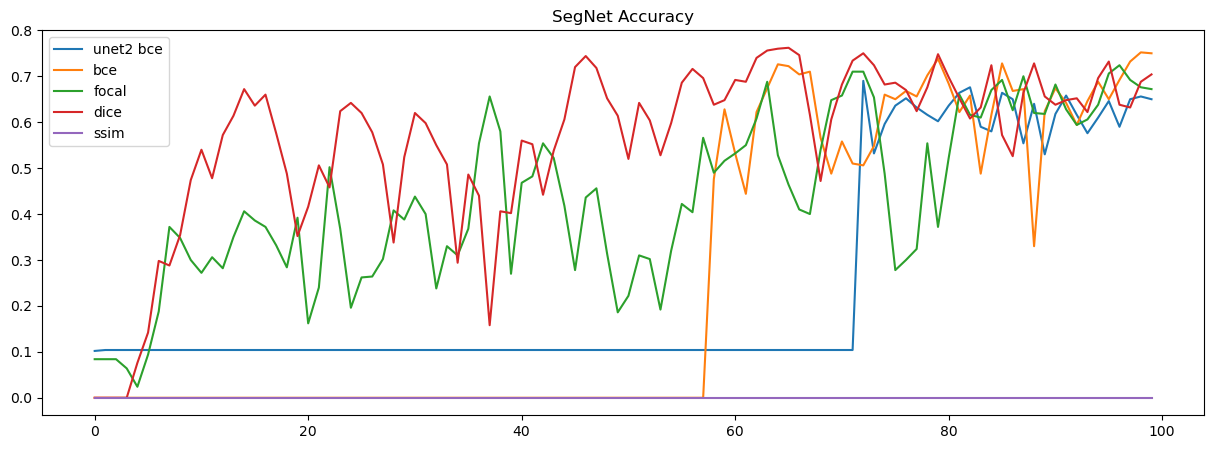

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(unet2_bce_val_acc, label='unet2 bce')
plt.plot(segnet_bce_val_acc, label='bce')
plt.plot(segnet_focal_val_acc, label='focal')
plt.plot(segnet_dice_val_acc, label='dice')
plt.plot(segnet_ssim_val_acc, label='ssim')
plt.title('SegNet Accuracy')
plt.legend()
plt.show()

Accuracy сильно колеблется - результаты неустойчивы. На последней эпохе самая высокая Accuracy у модели SegNet с BCE лоссом

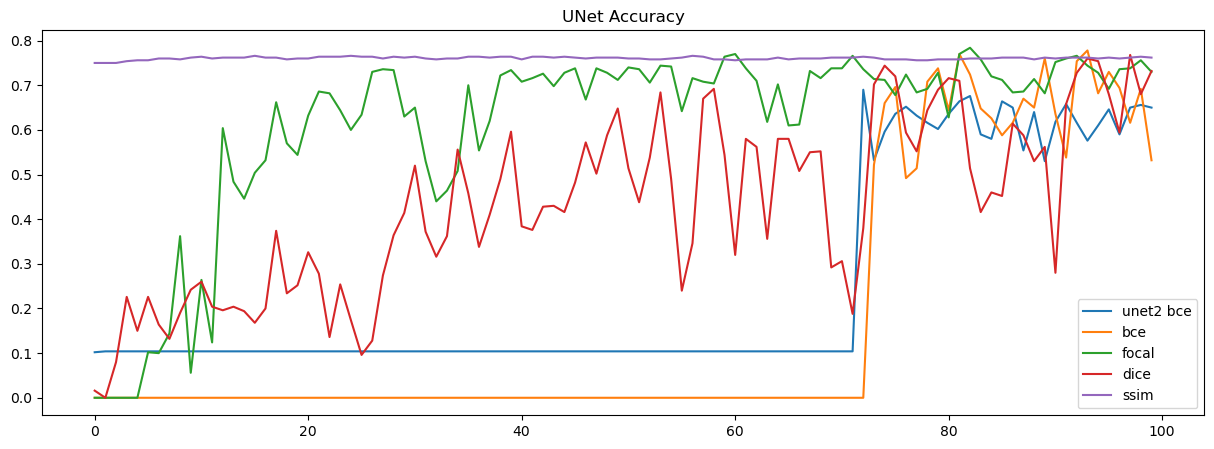

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(unet2_bce_val_acc, label='unet2 bce')
plt.plot(unet_bce_val_acc, label='bce')
plt.plot(unet_focal_val_acc, label='focal')
plt.plot(unet_dice_val_acc, label='dice')
plt.plot(unet_ssim_val_acc, label='ssim')
plt.title('UNet Accuracy')
plt.legend()
plt.show()

По колебаниям тут то же самое. Самый высокий Accuracy у Unet с Ssim лоссом, далее идет Focal лосс. Причем Unet2 с BCE лоссом показывает не сам лучшую accuracy.

Я бы сказала, что лучшая модель, в итоге, Unet с Ssim лоссом, т.к. у нее accuracy не колеблется, но сильно и не увеличился...